# **Ejercicio Opcional APIs**

Trabajar con Excels y CSVs descargados está bien para empezar, pero en el mundo real los datos cambian constantemente. Las APIs sirven para conectar nuestro código en Python directamente a bases de datos externas y extraer información actualizada.

Cada API tiene sus reglas. Algunas son de pago, otras requieren claves de acceso y todas organizan la información de manera distinta. Por eso, la principal habilidad al usar una API es leer su documentación. Vamos a usar la [PokéAPI](https://pokeapi.co/docs/v2), una base de datos pública y sin registro.

## El Reto: Registro Civil de Kanto

Tu trabajo es generar el Carnet de Identidad de los Pokémon que traen los entrenadores. Para ello no puedes fiarte de la memoria del entrenador, tienes que conectarte a la API, extraer los datos del Pokémon, limpiarlos y guardarlos y generar el documento de identidad.

Tu primer cliente quiere registrar a su Pikachu.

### Paso 1: La URL y la petición (requests.get)

Para pedirle información a la API, necesitamos la dirección exacta. Esta URL se construye uniendo tres partes en este caso:

1. URL Base (https://pokeapi.co/api/v2/): La raíz de la API. Todas las peticiones empiezan aquí.

2. Endpoint (pokemon): La categoría de datos que estamos consultando.

3. Recurso (pikachu): La entrada exacta que queremos buscar dentro de esa categoría.

Puedes revisar la documentación para identificar los endpoint y los recursos. También para comprobar la estructura en la que se guardan los datos, muy importante para luego extraer la verdadera información.

In [1]:
import requests
import pandas as pd
import numpy as np

endpoint = "pokemon"
recurso = "pikachu"

url = f"https://pokeapi.co/api/v2/{endpoint}/{recurso}"
datos_pikachu = requests.get(url)

Usamos la función requests.get() para hacer la consulta. Esta función no nos da los datos inmediatamente, sino una respuesta. Puedes probar haciendo un print del tipo. Si el código de estado de esa respuesta es 200, significa que la conexión ha sido un éxito y podemos proceder a leer los datos.

In [2]:
# Comprobamos el código de estado (200 = OK, 404 = No encontrado)
print(type(datos_pikachu), datos_pikachu)

<class 'requests.models.Response'> <Response [200]>


### Paso 2: Desempaquetar los datos (.json())

La variable datos_pikachu de nuestro paso anterior contiene la respuesta del servidor, pero no los datos legibles. Para extraer la información real, usa el método .json() y guárdalo en una variable llamada json_pikachu.

In [3]:
pikachu_json = datos_pikachu.json()
pikachu_json

{'abilities': [{'ability': {'name': 'static',
    'url': 'https://pokeapi.co/api/v2/ability/9/'},
   'is_hidden': False,
   'slot': 1},
  {'ability': {'name': 'lightning-rod',
    'url': 'https://pokeapi.co/api/v2/ability/31/'},
   'is_hidden': True,
   'slot': 3}],
 'base_experience': 112,
 'cries': {'latest': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/25.ogg',
  'legacy': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/legacy/25.ogg'},
 'forms': [{'name': 'pikachu',
   'url': 'https://pokeapi.co/api/v2/pokemon-form/25/'}],
 'game_indices': [{'game_index': 84,
   'version': {'name': 'red', 'url': 'https://pokeapi.co/api/v2/version/1/'}},
  {'game_index': 84,
   'version': {'name': 'blue', 'url': 'https://pokeapi.co/api/v2/version/2/'}},
  {'game_index': 84,
   'version': {'name': 'yellow',
    'url': 'https://pokeapi.co/api/v2/version/3/'}},
  {'game_index': 25,
   'version': {'name': 'gold', 'url': 'https://pokeapi.co/api/v2/version

Como ves, la API nos devuelve una cantidad absurda de información. 

Pero para nuestro Carnet de Identidad Pokémon, sólo necesitamos estos datos clave:

1. ID

2. Nombre

3. Tipo 1 y Tipo 2

4. Las 6 estadísticas base (HP, Ataque, Defensa, Ataque Especial, Defensa Especial, Velocidad)

5. Peso (weight) y Altura (height)

6. La imagen oficial del pokemon.

7. La descripción de su especie.

8. Una de sus habilidades.

In [4]:
id = pikachu_json['id']
nombre = pikachu_json['name']

# Tipos
tipo1 = pikachu_json['types'][0]['type']['name']
if len(pikachu_json['types']) > 1:
    tipo2 = pikachu_json['types'][1]['type']['name']
else:
    tipo2 = np.nan # Por si no hay tipo2
# tipo2 = pikachu_json['types'][1]['type']['name'] if len(pikachu_json['types']) > 1 else tipo2 = np.nan

# Estadísticas base
stats_dict = {}
for estad in pikachu_json['stats']:
    
    key = estad['stat']['name'].title() # clave con el nombre de estadística
    val = estad['base_stat'] # valor de la estadística
    
    # Creamos diccionario y añadimos a la lista de estadisticas
    stats_dict[key] = val

    
peso = pikachu_json['weight']
altura = pikachu_json['height']

# Imagen
img_url = pikachu_json['sprites']['other']['official-artwork']['front_default']

# Especie. Buscamos en el api por el id
url_spec = pikachu_json['species']['url']
species = requests.get(url_spec)
especie = species.json()
desc = especie['flavor_text_entries'][0]['flavor_text']


# Habilidad
habilidad = pikachu_json['abilities'][0]['ability']['name']



In [5]:
# Guardamos en diccionario los datos
pikachu = {
    'Id' : id,
    'Nombre' : nombre,
    'Tipo1' : tipo1,
    'Tipo2' : tipo2,
    'Peso' : peso,
    'Altura' : altura,
    'Imagen' : img_url,
    'Descripcion' : desc,
    'Habilidad' : habilidad,
}

### Paso 3: Pasando los datos a Pandas

Nuestra herramienta de trabajo final es un DataFrame. 
Crea un DataFrame desde el json_pikachu, puedes usar el constructor propio de DataFrame o el método json_normalize() de pandas.
Una vez lo hagás, haz un head().

In [6]:
# Juntar diccionarios
pikachu.update(stats_dict)

In [7]:
# Creamos DataFrame
pikachu_df = pd.DataFrame([pikachu])
pikachu_df.head()

,Id,Nombre,Tipo1,Tipo2,Peso,Altura,Imagen,Descripcion,Habilidad,Hp,Attack,Defense,Special-Attack,Special-Defense,Speed
0,25,pikachu,electric,NaN,60,4,https://raw.githubusercontent.com/PokeAPI/spri...,"When several of\nthese POKéMON\ngather, their ...",static,35,55,40,50,50,90


In [8]:
# Pasamos a df y 
# stats_df = pd.DataFrame([stats_dict])

# Le metemos multiíndice de stats
# stats_df.columns = pd.MultiIndex.from_product(
#     [['Estadísticas base'], stats_df.columns])
# pikachu_df = pd.concat([pikachu_df0, stats_df], axis=1)

El problema de los datos anidados

Si te fijas en la tabla que acabamos de generar, verás algo raro. Hay columnas (como abilities, stats o types) que en lugar de tener un valor simple como "60" o "Electric", tienen listas [...] o más diccionarios {...} metidos en la misma celda.

¿Por qué pasa esto? Porque el JSON original no es plano. Tiene una estructura de árbol: un Pokémon tiene una lista de estadísticas, y cada estadística tiene su propio nombre y valor.

Trabajar con tablas que tienen listas dentro de sus celdas es una dolor para hacer cálculos o gráficos y es lo más normal cuando obtienes la información desde una API.

### Paso 4: Crear una función de limpieza

Como funcionario de Datos en Kanto, no vas a hacer este proceso a mano solo para Pikachu. Tendrás que procesar cientos de solicitudes.

Crea la función procesar_pokemon(json_data). Esta función debe recibir el JSON crudo de cualquier Pokémon y devolver un diccionario limpio con las siguientes claves y condiciones:

1. id, nombre, habilidad, peso y altura.

2. tipo_1 y tipo_2. Si el Pokémon solo tiene un tipo, asígnale el valor None a tipo_2.

3. Una clave por cada una de las 6 estadísticas base (hp, attack, etc.).

4. El enlace de la imagen "front_default" del arte oficial que se encuentra dentro de sprites. Vas a tener que bucear bien dentro del diccionario para encontrarla.

5. La descripción de la especie del pokemon.

Una vez lo tengas pruébalo para crear un DataFrame con todos los valores limpios de Pikachu.

In [9]:
def procesar_pokemon(json_data):
    
    id = json_data['id']
    nombre = json_data['name']

    # Tipos
    tipo1 = json_data['types'][0]['type']['name']
    if len(json_data['types']) > 1:
        tipo2 = json_data['types'][1]['type']['name']
    else:
        tipo2 = np.nan # Por si no hay tipo2
        

    # Estadísticas base
    stats_dict = {}
    for estad in json_data['stats']:
        
        key = estad['stat']['name'].title() # clave con el nombre de estadística
        val = estad['base_stat'] # valor de la estadística
        
        # Creamos diccionario y añadimos a la lista de estadisticas
        stats_dict[key] = val

        
    peso = json_data['weight']
    altura = json_data['height']

    # Imagen
    img_url = json_data['sprites']['other']['official-artwork']['front_default']

    # Especie. Buscamos en el api por el id
    url_spec = json_data['species']['url']
    species = requests.get(url_spec)
    especie = species.json()
    desc = especie['flavor_text_entries'][0]['flavor_text']


    # Habilidad
    habilidad = json_data['abilities'][0]['ability']['name']


    
    # Guardamos en diccionario los datos
    pokemon_dict = {
        'Id' : id,
        'Nombre' : nombre,
        'Tipo1' : tipo1,
        'Tipo2' : tipo2,
        'Peso' : peso,
        'Altura' : altura,
        'Imagen' : img_url,
        'Descripcion' : desc,
        'Habilidad' : habilidad
    }
    # Juntar diccionarios
    pokemon_dict.update(stats_dict)
    
    pokemon_df = pd.DataFrame([pokemon_dict])
    
    return pokemon_df



In [10]:
# Probamos con pikachu
pika_df = procesar_pokemon(pikachu_json)
pika_df

,Id,Nombre,Tipo1,Tipo2,Peso,Altura,Imagen,Descripcion,Habilidad,Hp,Attack,Defense,Special-Attack,Special-Defense,Speed
0,25,pikachu,electric,NaN,60,4,https://raw.githubusercontent.com/PokeAPI/spri...,"When several of\nthese POKéMON\ngather, their ...",static,35,55,40,50,50,90


### Paso 5 - La descripción de la especie y la habilidad.

Si no te diste cuenta, te lo digo yo. Tanto la biografía de la especie como los detalles de su habilidad no vienen dentro del primer JSON. Lo que nos da la API en su lugar es un enlace (url).

Esto es una práctica estándar en el diseño de APIs. Si el servidor nos mandara toda la biografía en todos los idiomas y el texto de cada habilidad de golpe, la descarga sería enorme y lentísima. Por eficiencia, las APIs te entregan los datos superficiales y te dejan enlaces para que hagas nuevas peticiones solo si realmente necesitas profundizar.

Investiga tu JSON crudo o la documentación de la [PokéAPI](https://pokeapi.co/docs/v2) para encontrar dónde están escondidas esas URLs. Haz las nuevas requests, limpia los datos e introduce el texto de la biografía y de la habilidad en tu diccionario antes de pasarlo al DataFrame.

In [11]:
# Efecto
url_eff = pikachu_json['abilities'][0]['ability']['url']
effect = requests.get(url_eff)
efecto = effect.json()
desc_efecto = efecto['effect_entries'][2]['effect']
desc_efecto

"Whenever a move makes contact with this Pokémon, the move's user has a 30% chance of being paralyzed.\n\nPokémon that are immune to electric-type moves can still be paralyzed by this ability.\n\nOverworld: If the lead Pokémon has this ability, there is a 50% chance that encounters will be with an electric Pokémon, if applicable."

In [12]:
# Añadimos a nuestra función
def procesar_pokemon(json_data):
    
    id = json_data['id']
    nombre = json_data['name'].title()

    # Tipos
    tipo1 = json_data['types'][0]['type']['name'].title()
    if len(json_data['types']) > 1:
        tipo2 = json_data['types'][1]['type']['name'].title()
    else:
        tipo2 = np.nan # Por si no hay tipo2
        

    # Estadísticas base
    stats_dict = {}
    for estad in json_data['stats']:
        
        key = estad['stat']['name'].title() # clave con el nombre de estadística
        val = estad['base_stat'] # valor de la estadística
        
        # Creamos diccionario y añadimos a la lista de estadisticas
        stats_dict[key] = val

        
    peso = json_data['weight']
    altura = json_data['height']

    # Imagen
    img_url = json_data['sprites']['other']['official-artwork']['front_default']

    # Especie. Buscamos en el api por el id
    url_spec = json_data['species']['url']
    species = requests.get(url_spec)
    especie = species.json()
    desc = especie['flavor_text_entries'][0]['flavor_text']


    # Habilidad - cogemos el primero. Podemos meter un random entre las habilidades que tiene
    habilidad = json_data['abilities'][0]['ability']['name'].title()
    # Efecto
    url_eff = json_data['abilities'][0]['ability']['url']
    effect = requests.get(url_eff)
    efecto = effect.json()
    desc_efecto = efecto['effect_entries'][2]['effect']
    desc_efecto

    
    # Guardamos en diccionario los datos
    pokemon_dict = {
        'Id' : id,
        'Nombre' : nombre,
        'Tipo1' : tipo1,
        'Tipo2' : tipo2,
        'Peso' : peso,
        'Altura' : altura,
        'Imagen' : img_url,
        'Descripcion' : desc,
        'Habilidad' : habilidad,
        'Efecto' : desc_efecto
    }
    
    # Juntar diccionarios
    pokemon_dict.update(stats_dict)
    
    pokemon_df = pd.DataFrame([pokemon_dict])
    
    return pokemon_df



In [13]:
# Probamos con pikachu
pika_df = procesar_pokemon(pikachu_json)
pika_df

,Id,Nombre,Tipo1,Tipo2,Peso,Altura,Imagen,Descripcion,Habilidad,Efecto,Hp,Attack,Defense,Special-Attack,Special-Defense,Speed
0,25,Pikachu,Electric,NaN,60,4,https://raw.githubusercontent.com/PokeAPI/spri...,"When several of\nthese POKéMON\ngather, their ...",Static,Whenever a move makes contact with this Pokémo...,35,55,40,50,50,90


### Paso 6 - A crear el CIP!

Este paso es el más sencillo. Si tienes tu DataFrame con los datos limpios y listos sólo tienes que rellenar los campos de la función de abajo y comprueba como el CIP de Pikachu ya está listo. Ahora el entrenador de Pikachu ya puede llevarlo al centro pokemon para que le atiendan gratis.

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import requests
from io import BytesIO
import textwrap

def crear_carnet(nombre, pokedex_id, tipo_1, tipo_2, altura, peso, imagen, lista_stats, habilidad_nombre, habilidad_efecto, descripcion):
    """
    Genera un Carné de Identidad usando Matplotlib. Devuelve el objeto Figure.
    Agrupa absolutamente todo el texto en la columna central y elimina la fila inferior.
    """   
    fig = plt.figure(figsize=(14, 8.3))
    fig.suptitle(f"CARNET DE IDENTIDAD POKEMON: {nombre.upper()}", fontsize=18, fontweight='bold', y=0.95)
        
    grid = fig.add_gridspec(1, 3, width_ratios=[1, 1.3, 1.2])
   
    ax_img = fig.add_subplot(grid[0, 0])
    ax_img.axis('off')
    try:
        respuesta = requests.get(imagen)
        img = mpimg.imread(BytesIO(respuesta.content))
        ax_img.imshow(img)
    except:
        ax_img.text(0.5, 0.5, "Imagen no disponible", ha='center', va='center')
    
    ax_info = fig.add_subplot(grid[0, 1])
    ax_info.axis('off') 
    
    texto_tipo2 = tipo_2.capitalize() if tipo_2 else "-"
        
    ancho_columna = 45
    efecto_wrap = textwrap.fill(habilidad_efecto, width=ancho_columna)
    bio_wrap = textwrap.fill(descripcion, width=ancho_columna)
    
    info_text = (
        f"Nombre: {nombre.capitalize()}\n"
        f"No Pokedex: #{pokedex_id}\n"
        f"Tipo 1: {tipo_1.capitalize()}\n"
        f"Tipo 2: {texto_tipo2}\n"
        f"Altura: {altura/10:.1f} m\n"
        f"Peso: {peso/10:.1f} kg\n\n"
        f"Habilidad: {habilidad_nombre.capitalize()}\n"
        f"{efecto_wrap}\n\n"
        f"Biografia:\n"
        f"{bio_wrap}"
    )
        
    ax_info.text(0.0, 0.5, info_text, fontsize=12, linespacing=1.5, ha='left', va='center')
    
    ax_radar = fig.add_subplot(grid[0, 2], polar=True)
    
    categorias = ['PS', 'Ataque', 'Defensa', 'Atq. Esp.', 'Def. Esp.', 'Velocidad']
    N = len(categorias)
    
    valores = list(lista_stats) + [lista_stats[0]]
    angulos = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    
    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    
    ax_radar.set_xticks(angulos[:-1])
    ax_radar.set_xticklabels(categorias, color='dimgrey', size=11)
    ax_radar.set_rlabel_position(0)
    
    ax_radar.plot(angulos, valores, linewidth=2, linestyle='solid', color='royalblue')
    ax_radar.fill(angulos, valores, color='skyblue', alpha=0.4)
    ax_radar.set_title("Estadisticas Base", size=13, color='black', pad=15)

    plt.tight_layout()
    
    return fig

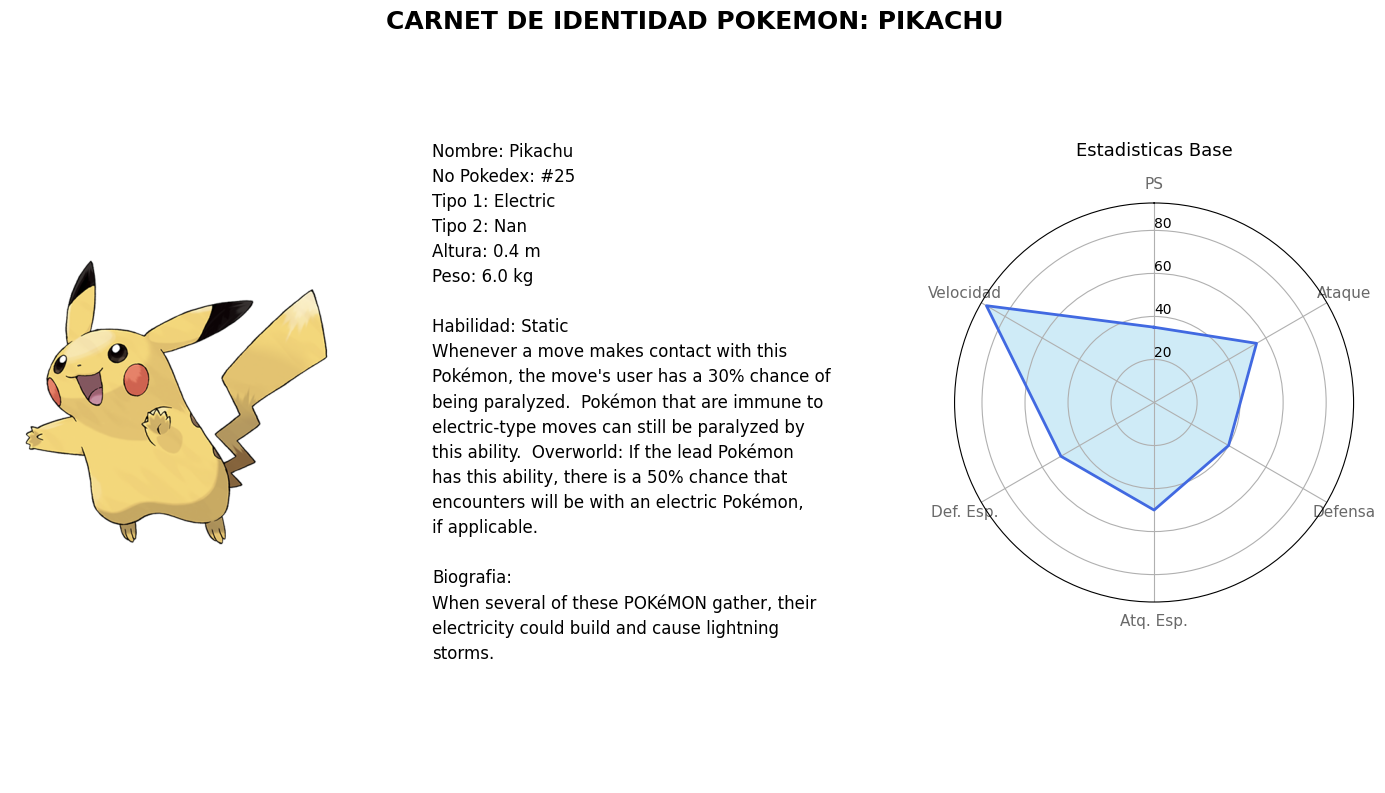

In [15]:
#Rellena los campos con la información de tu Dataframe y ejecuta!
crear_carnet(
    nombre= "pikachu", #El nombre de tu pokemon
    pokedex_id= "25", #Id del pokemon
    tipo_1= "electric", #Tipo 1 del pokemon
    tipo_2= "NaN", #el tipo 2
    altura= 4, #La altura del pokemon    
    peso= 60, #Su peso
    imagen= "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/official-artwork/25.png", #Su imagen
    lista_stats= (35,55,40,50,50,90), #Sus stats
    habilidad_nombre= "static", #EL nombre de su habilidad
    habilidad_efecto= "Whenever a move makes contact with this Pokémon, the move's user has a 30% chance of being paralyzed.\n\nPokémon that are immune to electric-type moves can still be paralyzed by this ability.\n\nOverworld: If the lead Pokémon has this ability, there is a 50% chance that encounters will be with an electric Pokémon, if applicable.", #La descripción del efecto
    descripcion= 'When several of\nthese POKéMON\ngather, their\x0celectricity could\nbuild and cause\nlightning storms.' #La descripción de la especie del pokemon
);

### Paso 7 - Creando la base de datos de Kanto

Hasta ahora has procesado Carnets de Identidad uno a uno. Pero el Registro Civil necesita digitalizar a los 151 Pokémon originales de la región de Kanto de una sola vez.

Sabes como hacer requests a la API, ahora en vez de traerte los datos de un pokemon tienes que conseguir los de 151.

Además, tienes una función para procesar los datos en bruto del json de un pokemon, asi que utilízala para convertir esos 151 json en un dataframe nuevo hecho y derecho con los 151 pokemon de kanto.

In [16]:
# Función para sacar entrada de de crear carnet de un pokemon en concreto tras añadirlo al df
def tupla_carnet(poke_df, num):
    nombre = poke_df.loc[0,'Nombre'].lower()
    id = str(num + 1)
    tipo_1 = poke_df.loc[0,'Tipo1'].lower()
    if pd.isna(poke_df.loc[0,'Tipo2']):
        tipo_2 = ''
    else:
        tipo_2 = poke_df.loc[0,'Tipo2'].lower()
    peso = int(poke_df.loc[0,'Peso'])
    altura = int(poke_df.loc[0,'Altura'])
    imagen = poke_df.loc[0,'Imagen']
    desc = poke_df.loc[0,'Descripcion']
    habilidad = poke_df.loc[0,'Habilidad'].lower()
    efecto = poke_df.loc[0,'Efecto']
    lista_stats = []
    lista_stats.append(int(poke_df.loc[0,'Hp']))
    lista_stats.append(int(poke_df.loc[0,'Attack']))
    lista_stats.append(int(poke_df.loc[0,'Defense']))
    lista_stats.append(int(poke_df.loc[0,'Special-Attack']))
    lista_stats.append(int(poke_df.loc[0,'Special-Defense']))
    lista_stats.append(int(poke_df.loc[0,'Speed']))
    lista_stats = tuple(lista_stats)
    
    return nombre, id, tipo_1, tipo_2, altura, peso, imagen, lista_stats, habilidad, efecto, desc

In [17]:
# Hacemos alguna prueba
pokemon_kanto = pd.DataFrame()

In [18]:
endpoint = "pokemon"
id = 28
poke = id
url = f"https://pokeapi.co/api/v2/{endpoint}/{poke}"
datos_pokemon = requests.get(url)
pokemon_json = datos_pokemon.json()

In [19]:
pokemon_df = procesar_pokemon(pokemon_json)
pokemon_kanto = pd.concat([pokemon_kanto, pokemon_df], axis=0, ignore_index=True)
poketupla = tupla_carnet(pokemon_df, id)

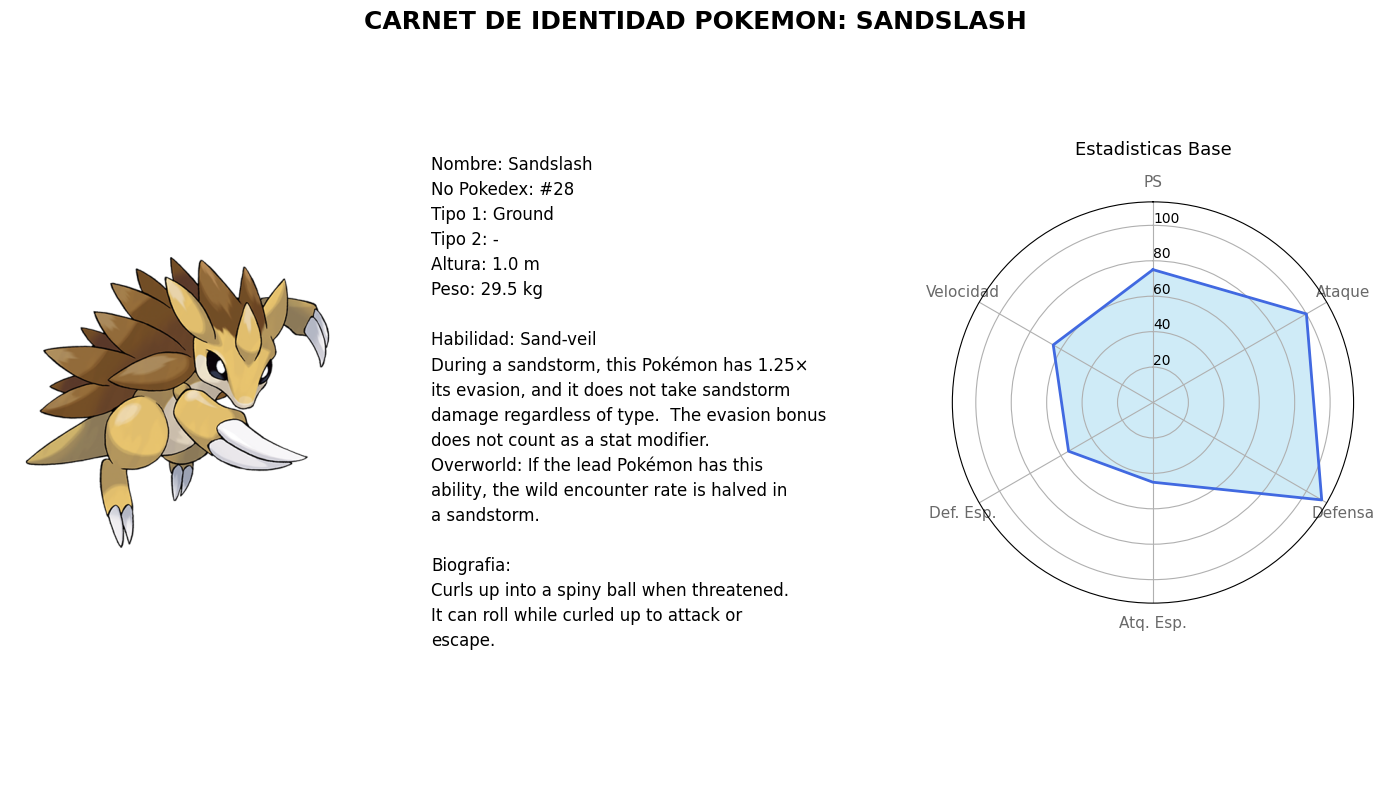

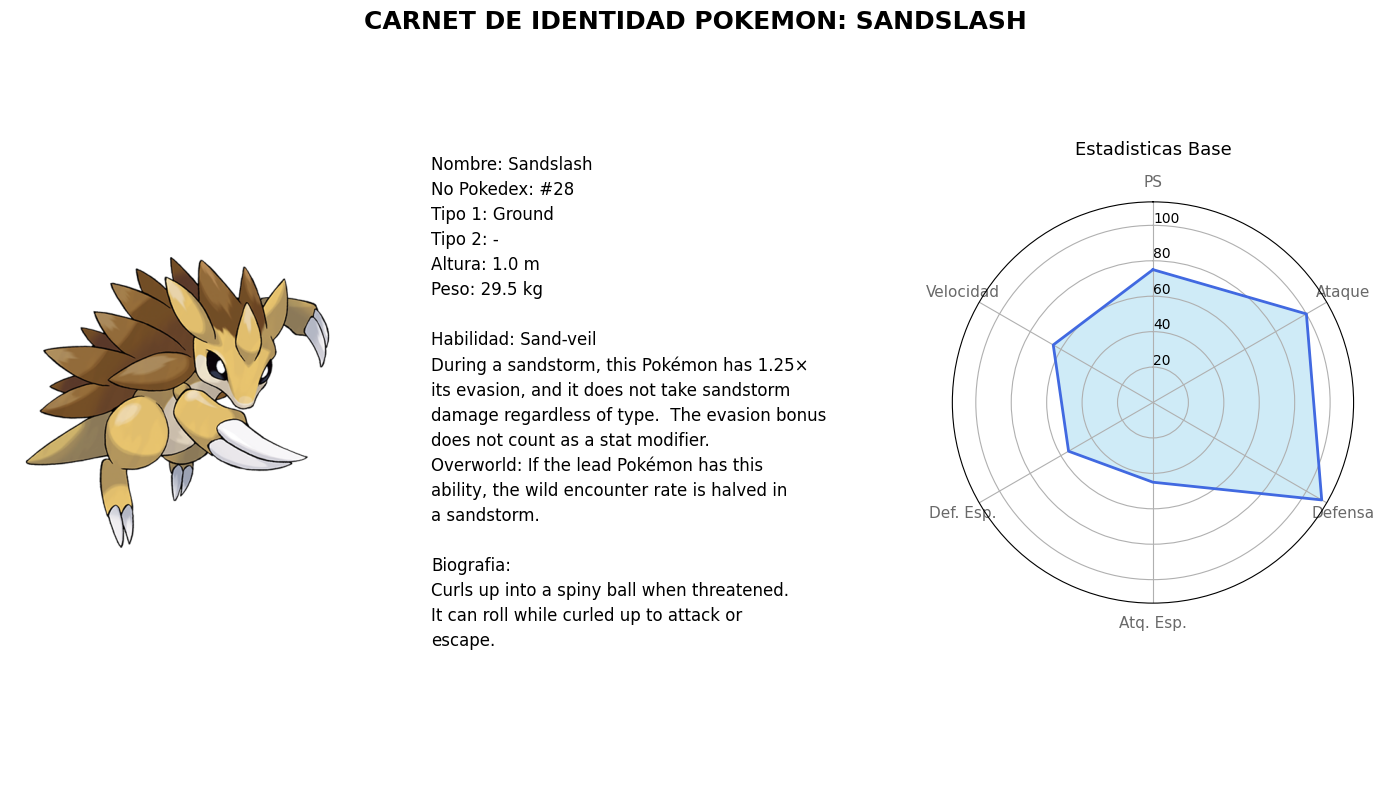

In [20]:
crear_carnet(
    nombre= pokemon_df.loc[0,'Nombre'].lower(), #El nombre de tu pokemon
    pokedex_id= id, #Id del pokemon
    tipo_1= pokemon_df.loc[0,'Tipo1'].lower(), #Tipo 1 del pokemon
    tipo_2= '' if pd.isna(pokemon_df.loc[0,'Tipo2']) else pokemon_df.loc[0,'Tipo2'].lower(), #el tipo 2
    altura= pokemon_df.loc[0,'Altura'], #La altura del pokemon    
    peso= pokemon_df.loc[0,'Peso'], #Su peso
    imagen= pokemon_df.loc[0,'Imagen'], #Su imagen
    lista_stats= (pokemon_df.loc[0,'Hp'], pokemon_df.loc[0,'Attack'], pokemon_df.loc[0,'Defense'], pokemon_df.loc[0,'Special-Attack'], pokemon_df.loc[0,'Special-Defense'], pokemon_df.loc[0,'Speed']), #Sus stats
    habilidad_nombre= pokemon_df.loc[0,'Habilidad'].lower(), #EL nombre de su habilidad
    habilidad_efecto= pokemon_df.loc[0,'Efecto'], #La descripción del efecto
    descripcion= pokemon_df.loc[0,'Descripcion'] #La descripción de la especie del pokemon
)
    # nombre = pokemon_df.loc[0,'Nombre'].lower()
    # id = str(id)
    # tipo_1 = pokemon_df.loc[0,'Tipo1'].lower()
    # if pd.isna(pokemon_df.loc[0,'Tipo2']):
    #     tipo_2 = ''
    # else:
    #     tipo_2 = '' if pd.isna(pokemon_df.loc[0,'Tipo2']) else pokemon_df.loc[0,'Tipo2'].lower() 
    # json_pokemon["types"][0]["type"]["name"][1] if json_pokemon["types"][0]["slot"] > 1 else None,
    # peso = int(pokemon_df.loc[0,'Peso'])
    # altura = int(pokemon_df.loc[0,'Altura'])
    # imagen = pokemon_df.loc[0,'Imagen']
    # desc = pokemon_df.loc[0,'Descripcion']
    # habilidad = pokemon_df.loc[0,'Habilidad'].lower()
    # efecto = pokemon_df.loc[0,'Efecto']
    # lista_stats = 

In [21]:
# pokemon_kanto

In [22]:
# Definimos df de pokemon de Kanto
pokemon_kanto = pd.DataFrame()

In [23]:
# Bucle para los 151 pokemon
for i in range(151):
    endpoint = "pokemon"
    poke = i + 1
    url = f"https://pokeapi.co/api/v2/{endpoint}/{poke}"
    datos_pokemon = requests.get(url)
    pokemon_json = datos_pokemon.json()
    
    pokemon_df = procesar_pokemon(pokemon_json)
    pokemon_kanto = pd.concat([pokemon_kanto, pokemon_df], axis=0, ignore_index=True)
    
pokemon_kanto

,Id,Nombre,Tipo1,Tipo2,Peso,Altura,Imagen,Descripcion,Habilidad,Efecto,Hp,Attack,Defense,Special-Attack,Special-Defense,Speed
0,1,Bulbasaur,Grass,Poison,69,7,https://raw.githubusercontent.com/PokeAPI/spri...,A strange seed was\nplanted on its\nback at bi...,Overgrow,When this Pokémon has 1/3 or less of its HP re...,45,49,49,65,65,45
1,2,Ivysaur,Grass,Poison,130,10,https://raw.githubusercontent.com/PokeAPI/spri...,"When the bulb on\nits back grows\nlarge, it ap...",Overgrow,When this Pokémon has 1/3 or less of its HP re...,60,62,63,80,80,60
2,3,Venusaur,Grass,Poison,1000,20,https://raw.githubusercontent.com/PokeAPI/spri...,The plant blooms\nwhen it is\nabsorbing solar ...,Overgrow,When this Pokémon has 1/3 or less of its HP re...,80,82,83,100,100,80
3,4,Charmander,Fire,NaN,85,6,https://raw.githubusercontent.com/PokeAPI/spri...,"Obviously prefers\nhot places. When\nit rains,...",Blaze,When this Pokémon has 1/3 or less of its HP re...,39,52,43,60,50,65
4,5,Charmeleon,Fire,NaN,190,11,https://raw.githubusercontent.com/PokeAPI/spri...,"When it swings\nits burning tail,\nit elevates...",Blaze,When this Pokémon has 1/3 or less of its HP re...,58,64,58,80,65,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,147,Dratini,Dragon,NaN,33,18,https://raw.githubusercontent.com/PokeAPI/spri...,Long considered a\nmythical POKéMON\nuntil rec...,Shed-Skin,"After each turn, this Pokémon has a 33% of bei...",41,64,45,50,50,50
147,148,Dragonair,Dragon,NaN,165,40,https://raw.githubusercontent.com/PokeAPI/spri...,人们相信它能操纵天气，\n所以在哈克龙栖息的湖里，\n供品总是源源不断。,Shed-Skin,"After each turn, this Pokémon has a 33% of bei...",61,84,65,70,70,70
148,149,Dragonite,Dragon,Flying,2100,22,https://raw.githubusercontent.com/PokeAPI/spri...,An extremely\nrarely seen\nmarine POKéMON. Its...,Inner-Focus,Ce Pokémon ne peut pas avoir peur.,91,134,95,100,100,80
149,150,Mewtwo,Psychic,NaN,1220,20,https://raw.githubusercontent.com/PokeAPI/spri...,It was created by\na scientist after\nyears of...,Pressure,Moves targetting this Pokémon use one extra PP...,106,110,90,154,90,130


### Paso 8 - EL último, ya acaba esto.

Ahora que tienes tu DataFrame con todos los pokemon de Kanto. Escoge uno aleatorio y hazle un CIP con la función de antes. Copia la imagen o guárdala para subirla a Slack y todos puedan ver a qué pokémon le has hecho el CIP!

In [ ]:
import random
i = random.randint(1, 151)
i

64

In [24]:
i = 64

In [25]:
pokemon_kanto.iloc[i]

Id                                                                65
Nombre                                                      Alakazam
Tipo1                                                        Psychic
Tipo2                                                            NaN
Peso                                                             480
Altura                                                            15
Imagen             https://raw.githubusercontent.com/PokeAPI/spri...
Descripcion        Its brain can out­\nperform a super­\ncomputer...
Habilidad                                                Synchronize
Efecto             Whenever this Pokémon is burned, paralyzed, or...
Hp                                                                55
Attack                                                            50
Defense                                                           45
Special-Attack                                                   135
Special-Defense                   

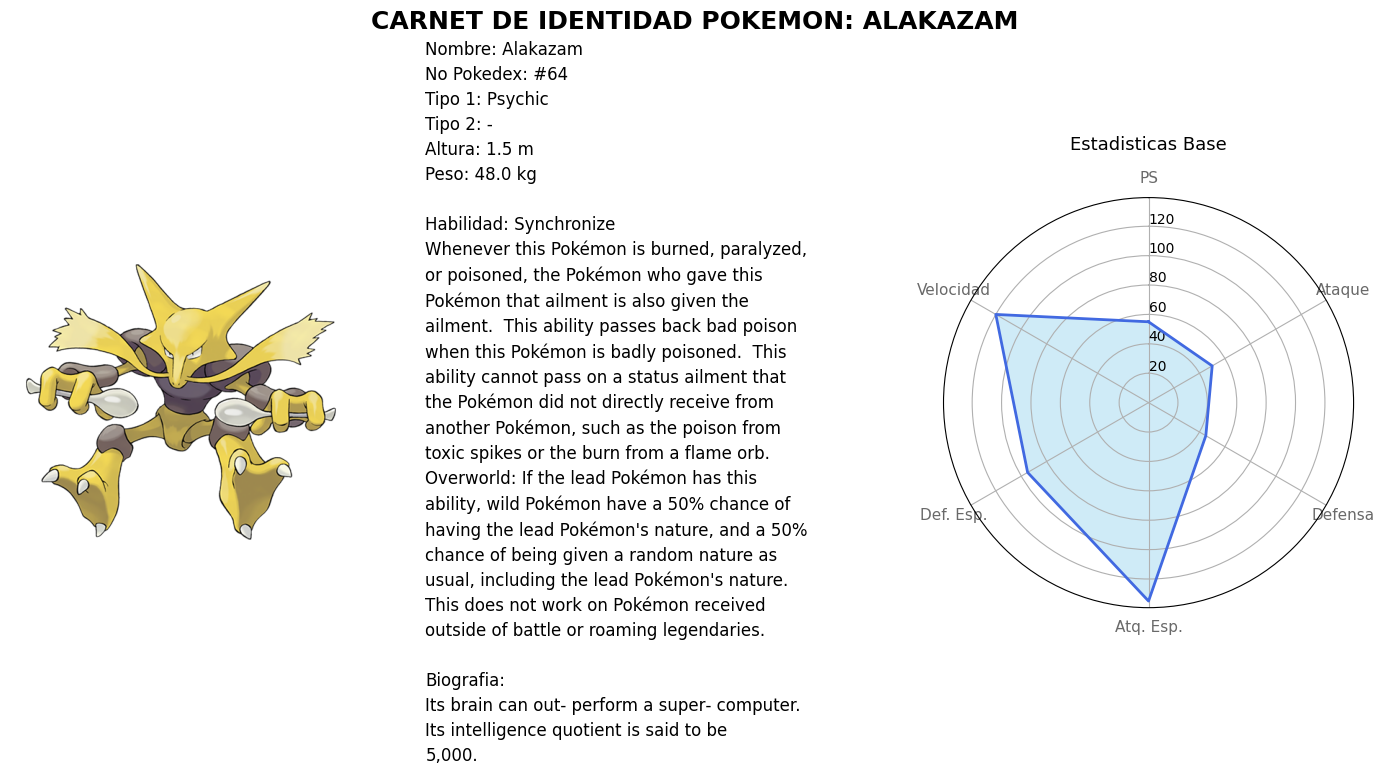

In [26]:
df = pokemon_kanto.loc[i,:]

crear_carnet(
    nombre= pokemon_kanto.loc[i,'Nombre'].lower(), #El nombre de tu pokemon
    pokedex_id= i, #Id del pokemon
    tipo_1= pokemon_kanto.loc[i,'Tipo1'].lower(), #Tipo 1 del pokemon
    tipo_2= '' if pd.isna(pokemon_kanto.loc[i,'Tipo2']) else pokemon_kanto.loc[i,'Tipo2'].lower(), #el tipo 2
    altura= pokemon_kanto.loc[i,'Altura'], #La altura del pokemon    
    peso= pokemon_kanto.loc[i,'Peso'], #Su peso
    imagen= pokemon_kanto.loc[i,'Imagen'], #Su imagen
    lista_stats= (pokemon_kanto.loc[i,'Hp'], pokemon_kanto.loc[i,'Attack'], pokemon_kanto.loc[i,'Defense'], pokemon_kanto.loc[i,'Special-Attack'], pokemon_kanto.loc[i,'Special-Defense'], pokemon_kanto.loc[i,'Speed']), #Sus stats
    habilidad_nombre= pokemon_kanto.loc[i,'Habilidad'].lower(), #EL nombre de su habilidad
    habilidad_efecto= pokemon_kanto.loc[i,'Efecto'], #La descripción del efecto
    descripcion= pokemon_kanto.loc[i,'Descripcion'] #La descripción de la especie del pokemon
);